In [1]:
import scipy as sp
from scipy.special import jv, hankel1, hankel2, yv, yvp, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum, angle
from utils import hl1_prime, hl2_prime, h_z_cpa_numerator, h_z_cpa, e_z_cpa, h_z_recursive_cpa, e_z_recursive_cpa

### We use the expression $\alpha = (-4i/k^2)(s-1)$ and compare this to the quasistatic limit

In [11]:
epsilon = 2.1 + 0.0j
x_min = 1e-5
x_max = 0.2
x = linspace(x_min, x_max, 1000)
l = 1
tm_s = h_z_cpa(l, x, epsilon)
alpha_retarded = (-4j/x**2)*(tm_s-1) # In units of R^2
alpha_static = (epsilon-1)/((epsilon+1)-1j*pi*(epsilon-1)*x**2/4)*2*pi # In units of R^2

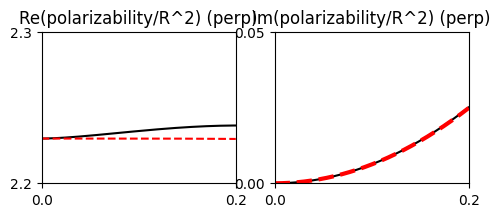

In [12]:
cm = 1/2.54
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14*cm, 5*cm))
ax1.plot(x, alpha_retarded.real, color="black")
ax1.plot(x, alpha_static.real, color="red", linestyle="dashed")
ax1.set_ylim(2.2, 2.3)
ax1.set_xlim(x_min, x_max)
ax1.set_xticks([x_min, x_max])
ax1.set_yticks([2.2, 2.3])
ax1.set_title("Re(polarizability/R^2) (perp)")

ax2.plot(x, alpha_retarded.imag, color="black")
ax2.plot(x, alpha_static.imag, color="red", linestyle="dashed", linewidth=3)
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(0, 0.05)
ax2.set_xticks([x_min, x_max]);
ax2.set_yticks([0, 0.05]);
ax2.set_title("Im(polarizability/R^2) (perp)");
plt.savefig("./paper/polarizability_perp.pdf");

### We now turn to the polarizability along the cylinder axis. We use the expression $\alpha = (-2i/k^2)(s-1)$ and compare this to the quasistatic limit

In [13]:
epsilon = 2.1 + 0.0j
x_min = 1e-5
x_max = 0.2
x = linspace(x_min, x_max, 1000)
l = 0
te_s = e_z_cpa(l, x, epsilon)
alpha_retarded = (-2j*R**2/x**2)*(te_s-1)
alpha_static = (epsilon-1)*pi*R**2/(1-1j*pi*(epsilon-1)*x**2/4)

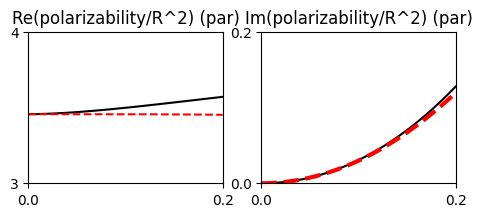

In [14]:
cm = 1/2.54
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14*cm, 5*cm))
ax1.plot(x, alpha_retarded.real, color="black")
ax1.plot(x, alpha_static.real, color="red", linestyle="dashed")
#ax1.set_ylim(2, 2.5)
ax1.set_xlim(x_min, x_max)
ax1.set_xticks([x_min, x_max])
ax1.set_yticks([3, 4])

ax2.plot(x, alpha_retarded.imag, color="black")
ax2.plot(x, alpha_static.imag, color="red", linestyle="dashed", linewidth=3)
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(0, 0.2)
ax2.set_xticks([x_min, x_max]);
ax2.set_yticks([0, 0.2]);
ax1.set_title("Re(polarizability/R^2) (par)")
ax2.set_title("Im(polarizability/R^2) (par)");
plt.savefig("./paper/polarizability_parallel.pdf");